# Industry Performance Dataset
## Exploratory Data Analysis and Machine Learning

### Project Objective

The objective of this project is to perform comprehensive Exploratory Data Analysis (EDA) and develop Machine Learning models to predict annual company revenue.

### Dataset

- Records: 15,000
- Variables: 12
- Target Variable: annual_revenue_million

### Machine Learning Problem

Supervised Learning - Regression

### Algorithms Used

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Extra Trees Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("data/industry_dataset_csv.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (15000, 12)


In [3]:
print("First 5 Records:")
display(df.head())

First 5 Records:


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [4]:
print("\nLast 5 Records:")
display(df.tail())


Last 5 Records:


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America
14999,15000,MediCorp_15000,Healthcare,USA,1473,879.67,29.31,2003,12998,2.0,14-03-2024,North America


In [5]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(15000, 12)


In [6]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['id', 'company_name', 'industry', 'country', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'created_date', 'region']


In [7]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                          int64
company_name                  str
industry                      str
country                       str
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
created_date                  str
region                        str
dtype: object


In [8]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

In [9]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (15000, 12)


In [11]:
# Date Conversion & Feature Engineering

df['created_date'] = pd.to_datetime(
    df['created_date'],
    dayfirst=True,
    errors='coerce'
)

df['created_year'] = df['created_date'].dt.year
df['created_month'] = df['created_date'].dt.month
df['created_quarter'] = df['created_date'].dt.quarter

df['company_age'] = (
    df['created_year'] - df['founded_year']
)

display(
    df[
        [
            'created_date',
            'founded_year',
            'created_year',
            'company_age'
        ]
    ].head()
)

,created_date,founded_year,created_year,company_age
0,2025-10-13,2010,2025,15
1,2025-12-01,2010,2025,15
2,2025-05-04,1996,2025,29
3,2026-02-01,1993,2026,33
4,2025-06-29,1996,2025,29


In [12]:
# Statistical Analysis

numeric_columns = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating'
]

display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
employee_count,15000.0,2606.862067,1430.562513,100.00,1379.000,2587.00,3839.00,5099.00
annual_revenue_million,15000.0,549.732707,288.244128,50.16,299.915,543.92,797.57,1049.96
profit_margin_percent,15000.0,25.012019,11.526187,5.00,15.050,24.91,35.10,45.00
founded_year,15000.0,2004.374000,8.606687,1990.00,1997.000,2004.00,2012.00,2019.00
customer_count,15000.0,50449.251867,28744.638830,500.00,25676.250,50726.50,75271.25,100495.00
market_rating,15000.0,2.513780,1.447998,0.00,1.200,2.50,3.80,5.00


In [13]:
stats_df = pd.DataFrame({
    'Variable': numeric_columns,
    'Skewness': [
        df[col].skew()
        for col in numeric_columns
    ],
    'Kurtosis': [
        df[col].kurtosis()
        for col in numeric_columns
    ]
})

display(stats_df)

,Variable,Skewness,Kurtosis
0,employee_count,0.002354,-1.187695
1,annual_revenue_million,0.027341,-1.187059
2,profit_margin_percent,0.002560,-1.202566
3,founded_year,0.020605,-1.189609
4,customer_count,-0.004866,-1.194714
5,market_rating,-0.020033,-1.205761


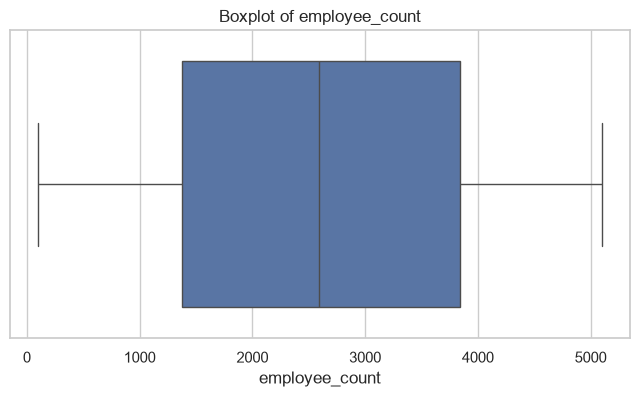

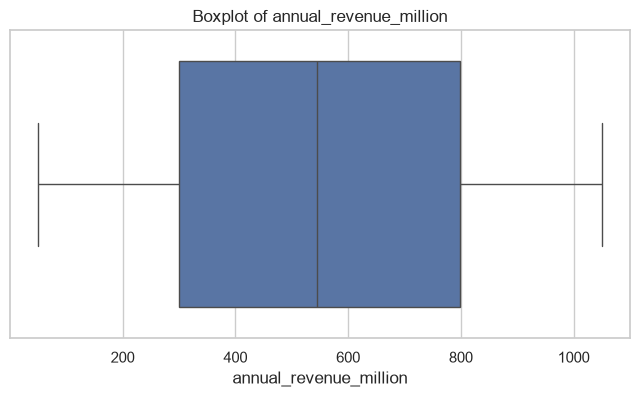

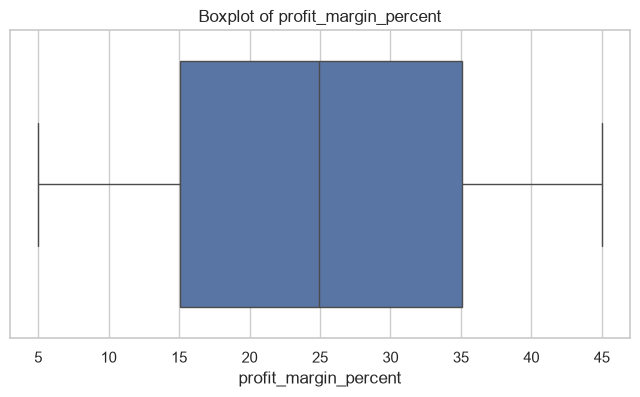

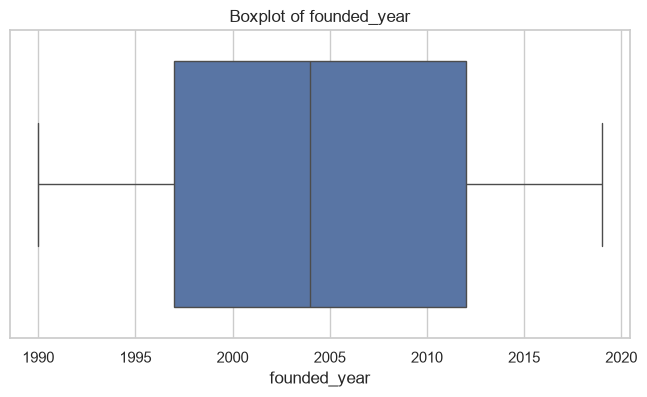

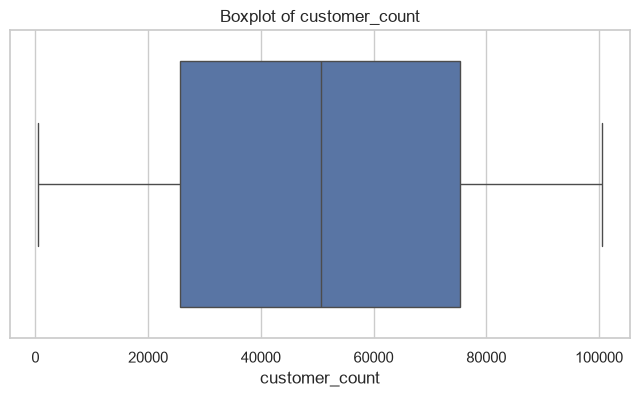

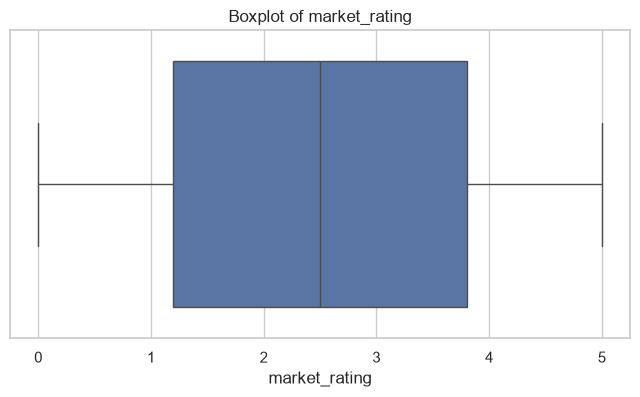

In [14]:
for col in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot of {col}')

    plt.show()

In [ ]:
# categorical analysis 

categorical_columns = [
    'industry',
    'country',
    'region'
]

for col in categorical_columns:

    print("\n", "=" * 50)
    print(col.upper())
    print("=" * 50)

    display(df[col].value_counts())


INDUSTRY


industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64


COUNTRY


country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64


REGION


region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64

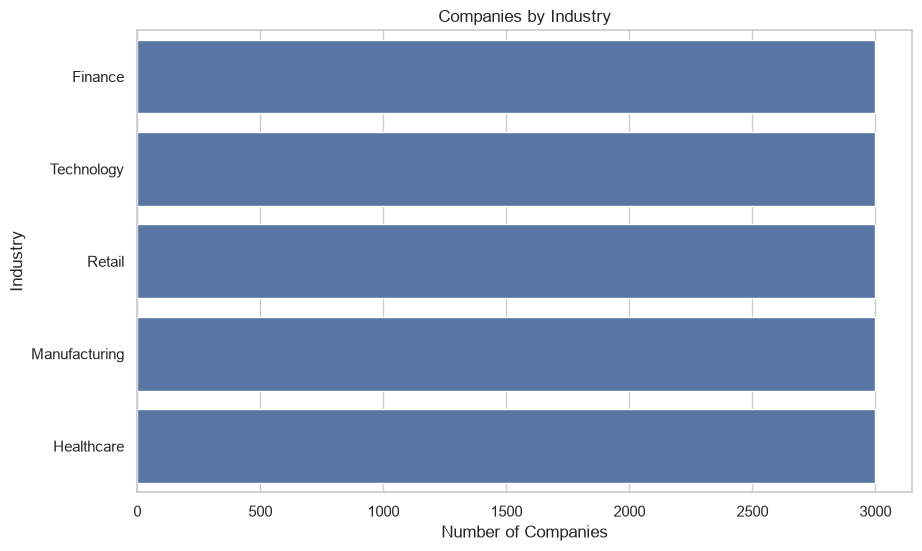

In [16]:
# Industry visualization

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='industry',
    order=df['industry'].value_counts().index
)

plt.title('Companies by Industry')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')

plt.show()

In [17]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return len(outliers), lower, upper


outlier_results = []

for col in numeric_columns:

    count, lower, upper = detect_outliers_iqr(
        df,
        col
    )

    outlier_results.append([
        col,
        count,
        lower,
        upper
    ])


outlier_df = pd.DataFrame(
    outlier_results,
    columns=[
        'Variable',
        'Outlier_Count',
        'Lower_Bound',
        'Upper_Bound'
    ]
)

display(outlier_df)

,Variable,Outlier_Count,Lower_Bound,Upper_Bound
0,employee_count,0,-2311.0000,7529.0000
1,annual_revenue_million,0,-446.5675,1544.0525
2,profit_margin_percent,0,-15.0250,65.1750
3,founded_year,0,1974.5000,2034.5000
4,customer_count,0,-48716.2500,149663.7500
5,market_rating,0,-2.7000,7.7000


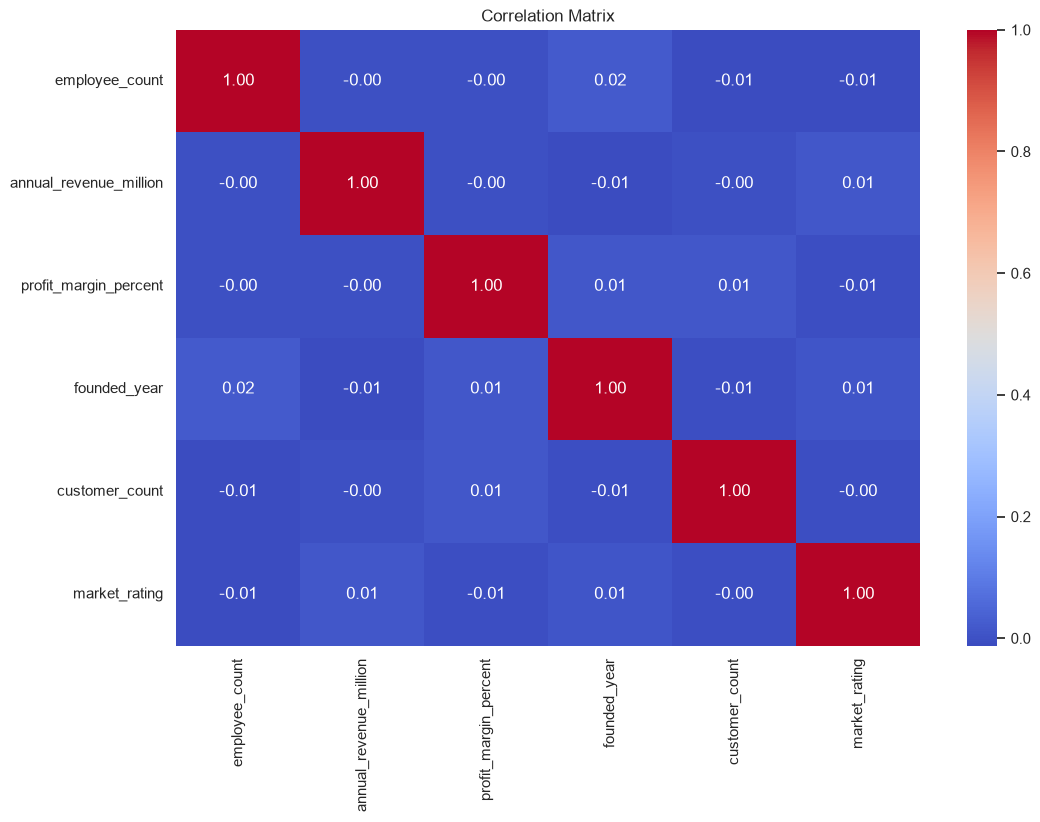

In [18]:
# Correlation

plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

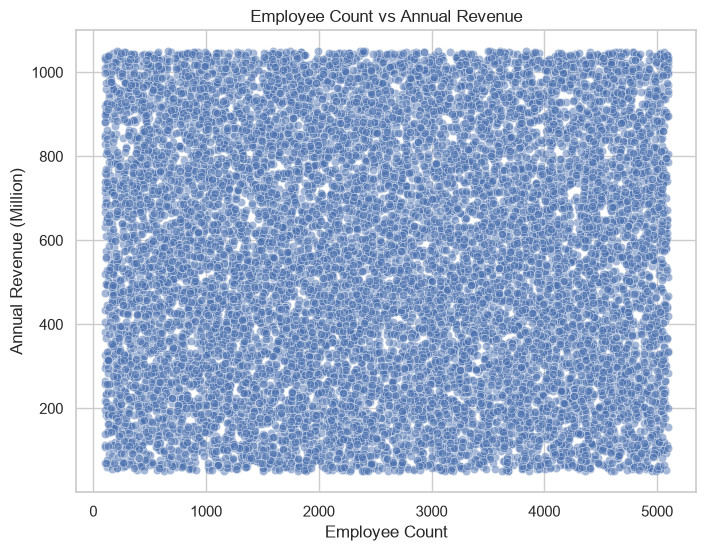

In [19]:
# Employee Count vs Revenue

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='employee_count',
    y='annual_revenue_million',
    alpha=0.5
)

plt.title(
    'Employee Count vs Annual Revenue'
)

plt.xlabel('Employee Count')
plt.ylabel('Annual Revenue (Million)')

plt.show()

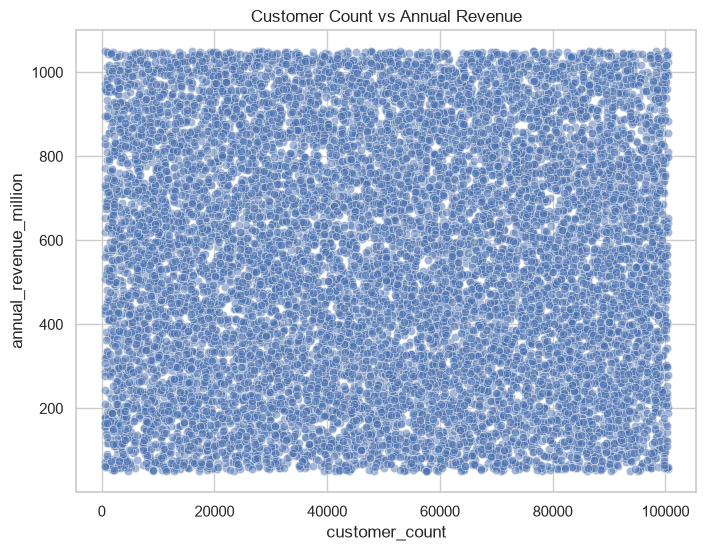

In [20]:
# Customer Count vs Revenue

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='customer_count',
    y='annual_revenue_million',
    alpha=0.5
)

plt.title(
    'Customer Count vs Annual Revenue'
)

plt.show()

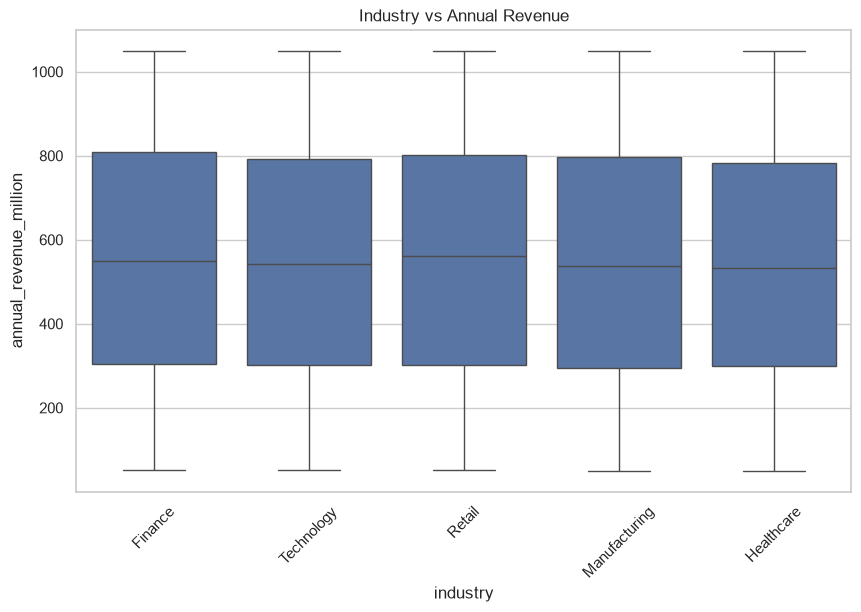

In [21]:
# Industry vs Revenue

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='industry',
    y='annual_revenue_million'
)

plt.title(
    'Industry vs Annual Revenue'
)

plt.xticks(rotation=45)

plt.show()

In [22]:
X = df.drop(
    columns=[
        'id',
        'company_name',
        'annual_revenue_million',
        'created_date'
    ]
)

y = df['annual_revenue_million']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['industry', 'country', 'employee_count', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'region', 'created_year', 'created_month', 'created_quarter', 'company_age']

Target:
annual_revenue_million


In [23]:
categorical_features = [
    'industry',
    'country',
    'region'
]

numerical_features = [
    'employee_count',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating',
    'created_year',
    'created_month',
    'created_quarter',
    'company_age'
]

In [24]:
# Split 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 12000
Testing records: 3000


In [25]:
# Preprocessing

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing completed!")

Preprocessing completed!


In [26]:
# Train Machine Learning Models

models = {

    'Linear Regression':
        LinearRegression(),

    'Decision Tree':
        DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ),

    'Random Forest':
        RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    'Gradient Boosting':
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    'Extra Trees':
        ExtraTreesRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
}

In [27]:
# Train 

trained_models = {}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    trained_models[name] = pipeline

    print("Completed!")

print("\nAll models trained.")

Training Linear Regression...
Completed!
Training Decision Tree...
Completed!
Training Random Forest...
Completed!
Training Gradient Boosting...
Completed!
Training Extra Trees...
Completed!

All models trained.


In [28]:
# Compare Models

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,248.278371,287.336587,-0.001235
2,Random Forest,248.727150,287.981268,-0.005732
3,Gradient Boosting,249.230858,288.885437,-0.012058
4,Extra Trees,250.440383,290.741479,-0.025104
1,Decision Tree,254.219991,297.176806,-0.070986


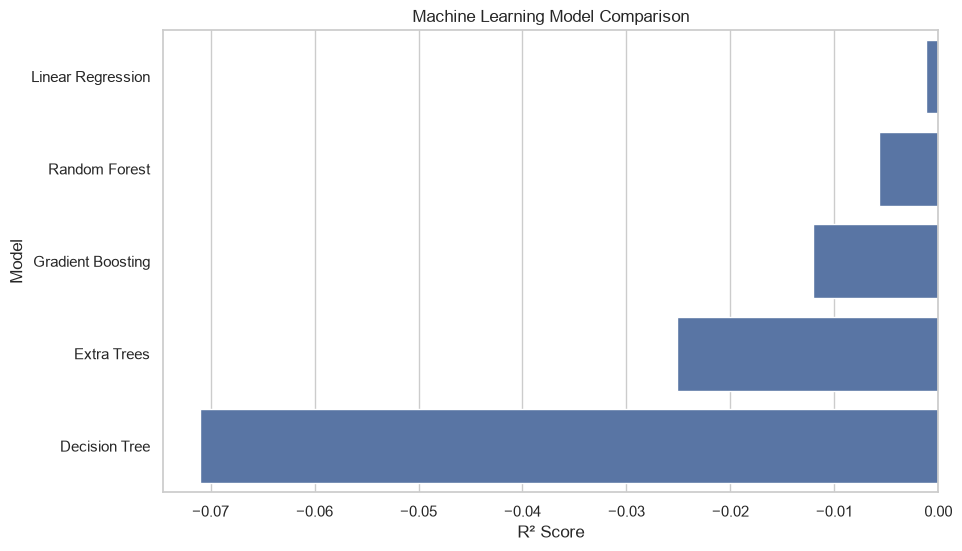

In [29]:
# Graph

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='R2 Score',
    y='Model'
)

plt.title(
    'Machine Learning Model Comparison'
)

plt.xlabel('R² Score')
plt.ylabel('Model')

plt.show()

In [30]:
# Select best model 

best_model_name = results_df.iloc[0]['Model']

best_model = trained_models[
    best_model_name
]

print("Best Model:")
print(best_model_name)

print("\nPerformance:")

display(
    results_df.iloc[[0]]
)

Best Model:
Linear Regression

Performance:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,248.278371,287.336587,-0.001235


In [31]:
# Actual vs Predicted 

best_predictions = best_model.predict(
    X_test
)

comparison = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': best_predictions
})

display(comparison.head(20))

,Actual Revenue,Predicted Revenue
0,129.01,549.137787
1,759.85,548.549185
2,296.36,560.653821
3,913.22,552.980053
4,411.28,553.637115
5,744.67,529.386883
6,511.28,552.120721
7,264.00,550.206571
8,889.57,540.865533
9,98.89,553.821279


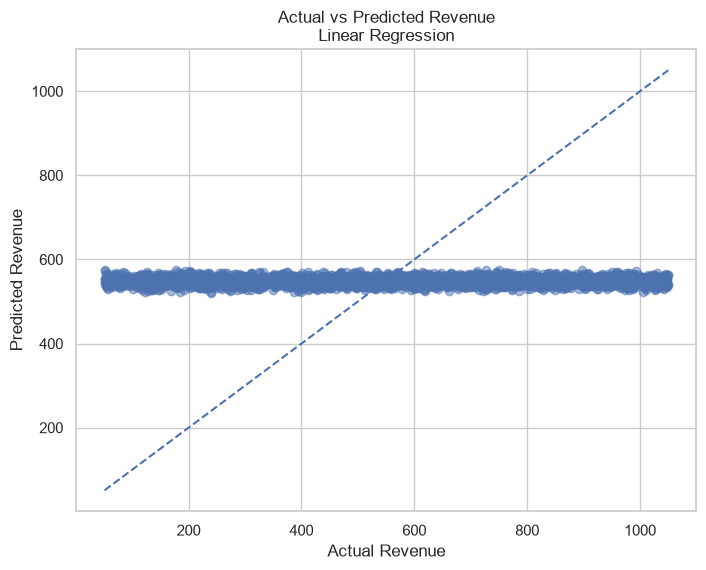

In [32]:
# plot 

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')

plt.title(
    f'Actual vs Predicted Revenue\n'
    f'{best_model_name}'
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.show()

In [ ]:
# Feature Importance

model_step = best_model.named_steps['model']
preprocessor_step = best_model.named_steps['preprocessor']

feature_names = preprocessor_step.get_feature_names_out()

# Tree-based models
if hasattr(model_step, 'feature_importances_'):

    importances = model_step.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

# Linear Regression
elif hasattr(model_step, 'coef_'):

    coefficients = model_step.coef_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Importance': np.abs(coefficients)
    })

else:

    feature_importance_df = pd.DataFrame()

# Sort features
if not feature_importance_df.empty:

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by='Importance',
            ascending=False
        )
        .head(20)
        .reset_index(drop=True)
    )

    print("Top 20 Important Features:")
    display(feature_importance_df)

else:

    print(
        "Feature importance is not available "
        "for this model."
    )

Top 20 Important Features:


,Feature,Coefficient,Importance
0,cat__industry_Retail,8.934481,8.934481
1,cat__industry_Manufacturing,-7.735016,7.735016
2,num__created_quarter,7.698523,7.698523
3,num__created_month,-5.777889,5.777889
4,cat__industry_Finance,5.223916,5.223916
5,num__market_rating,4.395172,4.395172
6,cat__industry_Healthcare,-4.278221,4.278221
7,cat__country_USA,2.397601,2.397601
8,cat__country_Germany,-2.368549,2.368549
9,cat__region_Europe,-2.368549,2.368549


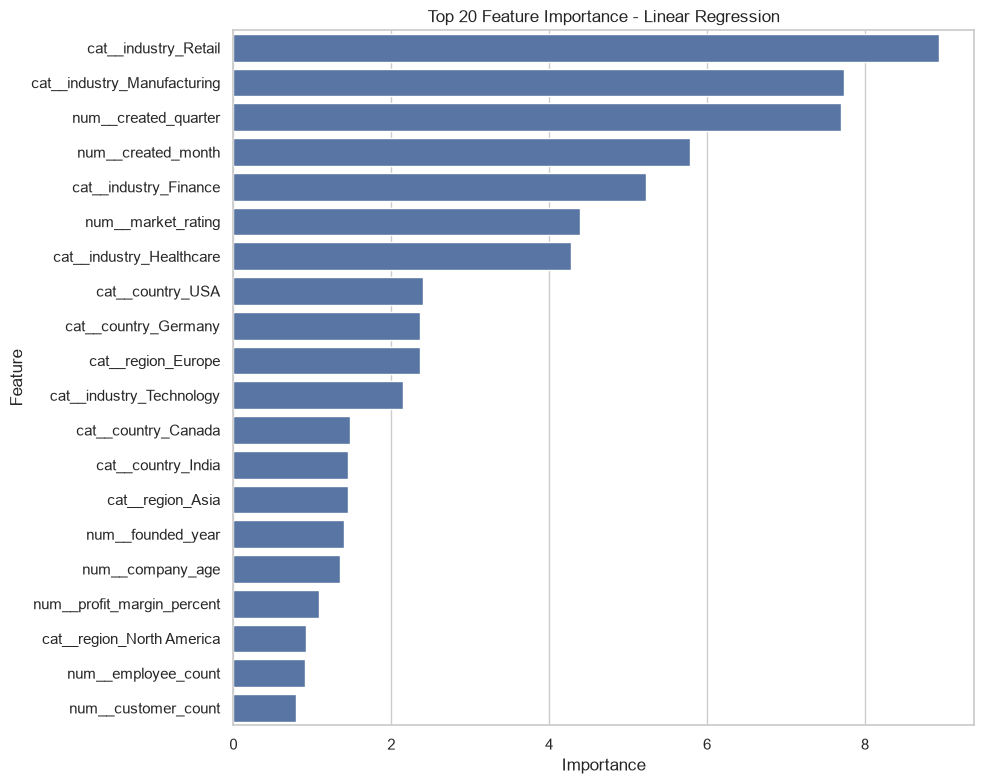

In [ ]:
# Graph

if not feature_importance_df.empty:

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importance_df,
        x='Importance',
        y='Feature'
    )

    plt.title(
        f'Top 20 Feature Importance - {best_model_name}'
    )

    plt.xlabel('Importance')
    plt.ylabel('Feature')

    plt.tight_layout()
    plt.show()

else:

    print("Feature importance cannot be plotted.")

In [43]:
# Predict a New Company

new_company = pd.DataFrame({

    'industry': ['Technology'],

    'country': ['India'],

    'employee_count': [3500],

    'profit_margin_percent': [35.5],

    'founded_year': [2015],

    'customer_count': [75000],

    'market_rating': [4.0],

    'region': ['Asia'],

    'created_year': [2026],

    'created_month': [10],

    'created_quarter': [4],

    'company_age': [11]

})

predicted_revenue = best_model.predict(
    new_company
)

print(
    "Predicted Annual Revenue:",
    round(predicted_revenue[0], 2),
    "million"
)

Predicted Annual Revenue: 552.91 million


In [44]:
# Save Model

joblib.dump(
    best_model,
    "models/industry_revenue_prediction_model.pkl"
)

print(
    "Best model saved successfully!"
)

Best model saved successfully!


In [45]:
# Save results

results_df.to_csv(
    "results/model_comparison_results.csv",
    index=False
)

if 'feature_importance_df' in globals():

    feature_importance_df.to_csv(
        "results/feature_importance.csv",
        index=False
    )

print("Results saved successfully!")

Results saved successfully!


# Conclusion

This project performed Exploratory Data Analysis and Machine Learning on a large-scale industry performance dataset containing 15,000 company records.

The analysis included:

- Data cleaning
- Missing-value analysis
- Duplicate detection
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Outlier detection using IQR
- Skewness and kurtosis analysis
- Correlation analysis
- Feature engineering
- Categorical encoding
- Feature scaling
- Train-test splitting

Five Machine Learning regression algorithms were evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Extra Trees Regressor

The target variable was `annual_revenue_million`.

The best-performing model was selected based on R² Score while also considering MAE and RMSE.

The model can be used to estimate annual company revenue based on employee count, industry, country, profit margin, customer count, market rating, region, company age, and other business characteristics.

The project demonstrates how Exploratory Data Analysis can be combined with Machine Learning to generate useful business insights and predictive analytics.